# Introduction

Google Trends gives us an estimate of search volume. Let's explore if search popularity relates to other kinds of data. Perhaps there are patterns in Google's search volume and the price of Bitcoin or a hot stock like Tesla. Perhaps search volume for the term "Unemployment Benefits" can tell us something about the actual unemployment rate?

Data Sources: <br>
<ul>
<li> <a href="https://fred.stlouisfed.org/series/UNRATE/">Unemployment Rate from FRED</a></li>
<li> <a href="https://trends.google.com/trends/explore">Google Trends</a> </li>  
<li> <a href="https://finance.yahoo.com/quote/TSLA/history?p=TSLA">Yahoo Finance for Tesla Stock Price</a> </li>    
<li> <a href="https://www.investing.com/crypto/bitcoin">Investing.com for BTC Stock Price</a> </li>
</ul>

# Import Statements

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_eng_float_format(accuracy=2, use_eng_prefix=True)

# Read the Data

Download and add the .csv files to the same folder as your notebook.

In [124]:
df_tesla = pd.read_csv('tsla_data.csv')
df_btc_search = pd.read_csv('bitcoin_trending_data.csv')
df_btc_price = pd.read_csv('bitcoin_price_data.csv')
df_unemp = pd.read_csv('unemp_data.csv')

# Data Exploration

### Tesla

**Challenge**: <br>
<ul>
<li>What are the shapes of the dataframes? </li>
<li>How many rows and columns? </li>
<li>What are the column names? </li>
<li>Complete the f-string to show the largest/smallest number in the search data column</li>
<li>Try the <code>.describe()</code> function to see some useful descriptive statistics</li>
<li>What is the periodicity of the time series data (daily, weekly, monthly)? </li>
<li>What does a value of 100 in the Google Trend search popularity actually mean?</li>
</ul>

In [125]:
display(df_tesla.info())
display(df_tesla.describe())

display(df_tesla.shape)
display(df_tesla.columns)

display(df_tesla.head())
display(df_tesla.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            124 non-null    object 
 1   tsla_web_search  124 non-null    int64  
 2   tsla_usd_close   124 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.0+ KB


None

,tsla_web_search,tsla_usd_close
count,124.00,124.00
mean,8.73,50.96
std,5.87,65.91
min,2.00,3.90
25%,3.75,7.35
50%,8.00,44.65
75%,12.00,58.99
max,31.00,498.32


(124, 3)

Index(['month', 'tsla_web_search', 'tsla_usd_close'], dtype='object')

,month,tsla_web_search,tsla_usd_close
0,6/1/10,3,4.77
1,7/1/10,3,3.99
2,8/1/10,2,3.90
3,9/1/10,2,4.08
4,10/1/10,2,4.37


,month,tsla_web_search,tsla_usd_close
119,5/1/20,16,167.00
120,6/1/20,17,215.96
121,7/1/20,24,286.15
122,8/1/20,23,498.32
123,9/1/20,31,407.34


In [126]:
print(f'Largest value for Tesla in Web Search: {df_tesla.tsla_web_search.max()}')
print(f'Smallest value for Tesla in Web Search: {df_tesla.tsla_web_search.min()}')

Largest value for Tesla in Web Search: 31
Smallest value for Tesla in Web Search: 2


### Unemployment Data

In [127]:
max_index = df_unemp.unemp_web_search.idxmax()
min_index = df_unemp.unemp_web_search.idxmin()

#can use idxmax/min but better off using .iloc[max/min index], showcasing the difference between both approaches below
print(f'Largest value for unemp Benefits in Web Search: {df_unemp.unemp_web_search.max()} at id: {df_unemp.unemp_web_search.idxmax()}')
print(f'Smallest value for unemp Benefits in Web Search: {df_unemp.iloc[min_index].unemp_web_search} at date: {df_unemp.iloc[min_index].month}')

Largest value for unemp Benefits in Web Search: 100 at id: 195
Smallest value for unemp Benefits in Web Search: 4 at date: 2015-05


In [128]:
display(df_unemp.info())
display(df_unemp.describe())

display(df_unemp.shape)
display(df_unemp.columns)

display(df_unemp.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             264 non-null    object 
 1   unemp_web_search  264 non-null    int64  
 2   unemp_rate        261 non-null    float64
 3   Unnamed: 3        0 non-null      float64
 4   Unnamed: 4        0 non-null      float64
 5   Unnamed: 5        0 non-null      float64
 6   Unnamed: 6        0 non-null      float64
 7   Unnamed: 7        0 non-null      float64
 8   Unnamed: 8        0 non-null      float64
 9   Unnamed: 9        0 non-null      float64
 10  Unnamed: 10       0 non-null      float64
dtypes: float64(9), int64(1), object(1)
memory usage: 22.8+ KB


None

,unemp_web_search,unemp_rate,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
count,264.00,261.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
mean,13.59,5.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,16.31,2.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,4.00,3.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,6.00,4.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.50,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,12.25,6.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,100.00,14.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(264, 11)

Index(['month', 'unemp_web_search', 'unemp_rate', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10'],
      dtype='object')

,month,unemp_web_search,unemp_rate,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,2004-01,9,5.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-02,8,5.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2004-03,7,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004-04,8,5.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004-05,6,5.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
#realized last 3 rows are missing important vals + bunch of NaN columns in the unemp data
#easiest way right now is to remove last 3 rows and all columns after 3rd:
df_unemp = df_unemp.iloc[:-3, :3] #can also do this:df_unemp.drop(df_unemp.columns[3:], axis=1, inplace=True)

#if we had sporadic NaN columns instead, we could divide this process into 2 pieces
#where we remove last 3 rows first and then systematically remove NaN columns

# df_unemp = df_unemp.iloc[:-3,]
# display(df_unemp.tail())
# print("now that we removed the last 3 rows with missing unemp_rate data, we can remove NaN cols")
# unemp_columns_with_na = df_unemp.loc[:, df_unemp.isna().any()].columns
# df_unemp.drop(columns=unemp_columns_with_na, inplace=True)
df_unemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             261 non-null    object 
 1   unemp_web_search  261 non-null    int64  
 2   unemp_rate        261 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.2+ KB


### Bitcoin

In [130]:
print(df_btc_search.shape)
print(df_btc_search.columns)

display(df_btc_search.describe())
display(df_btc_search.head())

(262, 2)
Index(['week', 'trend_score'], dtype='object')


,trend_score
count,262.00
mean,30.79
std,15.48
min,12.00
25%,20.00
50%,26.00
75%,36.00
max,100.00


,week,trend_score
0,12/6/20,25
1,12/13/20,41
2,12/20/20,39
3,12/27/20,62
4,1/3/21,93


In [131]:
print(df_btc_price.shape)
print(df_btc_price.columns)

display(df_btc_price.describe())
display(df_btc_price.head())

(1864, 7)
Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change'], dtype='object')


,Date,Price,Open,High,Low,Vol.,Change
count,1864,1864,1864,1864,1864,1864,1864
unique,1864,1859,1859,1860,1863,1786,887
top,11/1/20,"16,831.80","37,294.30","57,697.40","34,357.40",56.24K,0.24%
freq,1,2,2,2,2,3,9


,Date,Price,Open,High,Low,Vol.,Change
0,12/8/25,"90,933.50","90,413.60","92,269.10","89,640.70",52.96K,0.57%
1,12/7/25,"90,413.60","89,209.80","91,736.80","87,747.60",38.67K,1.35%
2,12/6/25,"89,209.80","89,333.60","90,176.50","88,929.50",30.14K,-0.14%
3,12/5/25,"89,333.60","92,082.80","92,676.40","88,218.40",61.14K,-2.99%
4,12/4/25,"92,082.80","93,437.20","94,043.90","90,933.20",60.28K,-1.45%


# Data Cleaning

### Check for Missing Values

**Challenge**: Are there any missing values in any of the dataframes? If so, which row/rows have missing values? How many missing values are there?

In [132]:
#can add .values.any() at the end of isna() to check for quick yes/no

print(f'Missing values for Tesla?: {df_tesla.isna().values.any()}')
print(f'Missing values for unemp?: {df_unemp.isna().values.any()}')
print(f'Missing values for BTC Search?: {df_btc_search.isna().values.any()}')
print(f'Missing values for BTC Price?: {df_btc_price.isna().values.any()}')

Missing values for Tesla?: False
Missing values for unemp?: False
Missing values for BTC Search?: False
Missing values for BTC Price?: False


In [133]:
# .values.sum() gives total of na cells whereas .sum() gives na cell count by the columns
print(f'Number of missing values for unemp: {df_unemp.isna().values.sum()}')
print(f'Number of missing values for unemp: {df_unemp.isna().sum()}')

Number of missing values for unemp: 0
Number of missing values for unemp: month               0
unemp_web_search    0
unemp_rate          0
dtype: int64


**Challenge**: Remove any missing values that you found.

In [134]:
df_unemp.dropna(inplace=True)
print(f'Number of missing values for unemp: {df_unemp.isna().values.sum()}')
# output: Number of missing values for unemp: 0

Number of missing values for unemp: 0


# Data Type Cleanup #
Upon spotting non-numeric data types for numeric row values,
we now look at two different ways to update data types, **one manual** and more **automated with loops**.



In [135]:
#cleanup for data tyoe from obj to numeric
df_btc_price['Price'] = df_btc_price['Price'].str.replace(',', '').str.replace('$', '')
df_btc_price['Price'] = pd.to_numeric(df_btc_price['Price'], errors='coerce')

#instead of above single fix approach, can automate all via below:
#Use a dictionary to store dataframes
dfs = {
    'btc_price': df_btc_price,
    'btc_search': df_btc_search,
}
numeric_cols = {
    'btc_price': ['Price', 'Open', 'High', 'Low', 'Vol.'],
    'btc_search': ['trend_score'],
}

for df_name, cols in numeric_cols.items():
    df = dfs[df_name]  # No eval() needed
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

## Convert Strings to DateTime Objects ##

Now, similar approach for data type cleanup for datetime

**Challenge**: Check the data type of the entries in the DataFrame MONTH or DATE columns. Convert any strings in to Datetime objects. Do this for all 4 DataFrames. Double check if your type conversion was successful.

In [136]:
df_btc_price.rename(columns={"Date":"date"}, inplace=True)

df_tesla['month'] = pd.to_datetime(df_tesla.month, format='%m/%d/%y')
df_btc_search['week'] = pd.to_datetime(df_btc_search.week, format='%m/%d/%y')
df_btc_price['date'] = pd.to_datetime(df_btc_price.date, format='%m/%d/%y')
df_unemp['month'] = pd.to_datetime(df_unemp.month, format='%Y-%m')

#sort df_btc_price
df_btc_price.sort_values(by=['date'], inplace=True)
df_btc_price.head()

,date,Price,Open,High,Low,Vol.,Change
1863,2020-11-01,13.76k,NaN,NaN,NaN,NaN,-0.27%
1862,2020-11-02,13.56k,NaN,NaN,NaN,NaN,-1.44%
1861,2020-11-03,14.02k,NaN,NaN,NaN,NaN,3.38%
1860,2020-11-04,14.15k,NaN,NaN,NaN,NaN,0.90%
1859,2020-11-05,15.59k,NaN,NaN,NaN,NaN,10.19%


In [137]:
display(df_tesla.head(n=3))
display(df_btc_search.head(n=3))
display(df_btc_price.head(n=3))
display(df_unemp.head(n=3))

,month,tsla_web_search,tsla_usd_close
0,2010-06-01,3,4.77
1,2010-07-01,3,3.99
2,2010-08-01,2,3.90


,week,trend_score
0,2020-12-06,25
1,2020-12-13,41
2,2020-12-20,39


,date,Price,Open,High,Low,Vol.,Change
1863,2020-11-01,13.76k,NaN,NaN,NaN,NaN,-0.27%
1862,2020-11-02,13.56k,NaN,NaN,NaN,NaN,-1.44%
1861,2020-11-03,14.02k,NaN,NaN,NaN,NaN,3.38%


,month,unemp_web_search,unemp_rate
0,2004-01-01,9,5.70
1,2004-02-01,8,5.60
2,2004-03-01,7,5.80


### Converting from Daily to Monthly Data

[Pandas .resample() documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.resample.html) <br>

In [138]:
#df_btc_price is daily data and df_btc_search is weekly
df_btc_price = df_btc_price.resample(rule='ME', on='date').last()
#currently showing one more month (2020-11-30) so we will take that out to
#make the shapes much perfectly instead of a single row difference
df_btc_price = df_btc_price.iloc[1:]
display(df_btc_price.head(n=3))

df_btc_search = df_btc_search.resample(rule='ME', on='week').last()
display(df_btc_search.head(n=3))

print(f"shape for price -> {df_btc_price.shape} and seach trending -> {df_btc_search.shape}") #both now have 61 rows
display(df_btc_price.info())
display(df_btc_search.info())

,Price,Open,High,Low,Vol.,Change
date,,,,,,
2020-12-31,28.95k,NaN,NaN,NaN,NaN,0.28%
2021-01-31,33.11k,NaN,NaN,NaN,NaN,-3.43%
2021-02-28,45.16k,NaN,NaN,NaN,NaN,-2.11%


,trend_score
week,
2020-12-31,62
2021-01-31,51
2021-02-28,59


shape for price -> (61, 6) and seach trending -> (61, 1)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2020-12-31 to 2025-12-31
Freq: ME
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   61 non-null     float64
 1   Open    0 non-null      float64
 2   High    0 non-null      float64
 3   Low     0 non-null      float64
 4   Vol.    0 non-null      float64
 5   Change  61 non-null     object 
dtypes: float64(5), object(1)
memory usage: 3.3+ KB


None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2020-12-31 to 2025-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   trend_score  61 non-null     int64
dtypes: int64(1)
memory usage: 976.0 bytes


None

# Data Visualisation

### Notebook Formatting & Style Helpers

### Tesla Stock Price v.s. Search Volume

**Challenge:** Plot the Tesla stock price against the Tesla search volume using a line chart and two different axes. Label one axis 'TSLA Stock Price' and the other 'Search Trend'.

**Challenge**: Add colours to style the chart. This will help differentiate the two lines and the axis labels. Try using one of the blue [colour names](https://matplotlib.org/3.1.1/gallery/color/named_colors.html) for the search volume and a HEX code for a red colour for the stock price.
<br>
<br>
Hint: you can colour both the [axis labels](https://matplotlib.org/3.3.2/api/text_api.html#matplotlib.text.Text) and the [lines](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.lines.Line2D.html#matplotlib.lines.Line2D) on the chart using keyword arguments (kwargs).  

**Challenge**: Make the chart larger and easier to read.
1. Increase the figure size (e.g., to 14 by 8).
2. Increase the font sizes for the labels and the ticks on the x-axis to 14.
3. Rotate the text on the x-axis by 45 degrees.
4. Make the lines on the chart thicker.
5. Add a title that reads 'Tesla Web Search vs Price'
6. Keep the chart looking sharp by changing the dots-per-inch or [DPI value](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.figure.html).
7. Set minimum and maximum values for the y and x axis. Hint: check out methods like [set_xlim()](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.set_xlim.html).
8. Finally use [plt.show()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.show.html) to display the chart below the cell instead of relying on the automatic notebook output.

In [139]:
import matplotlib.dates as mdates

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')


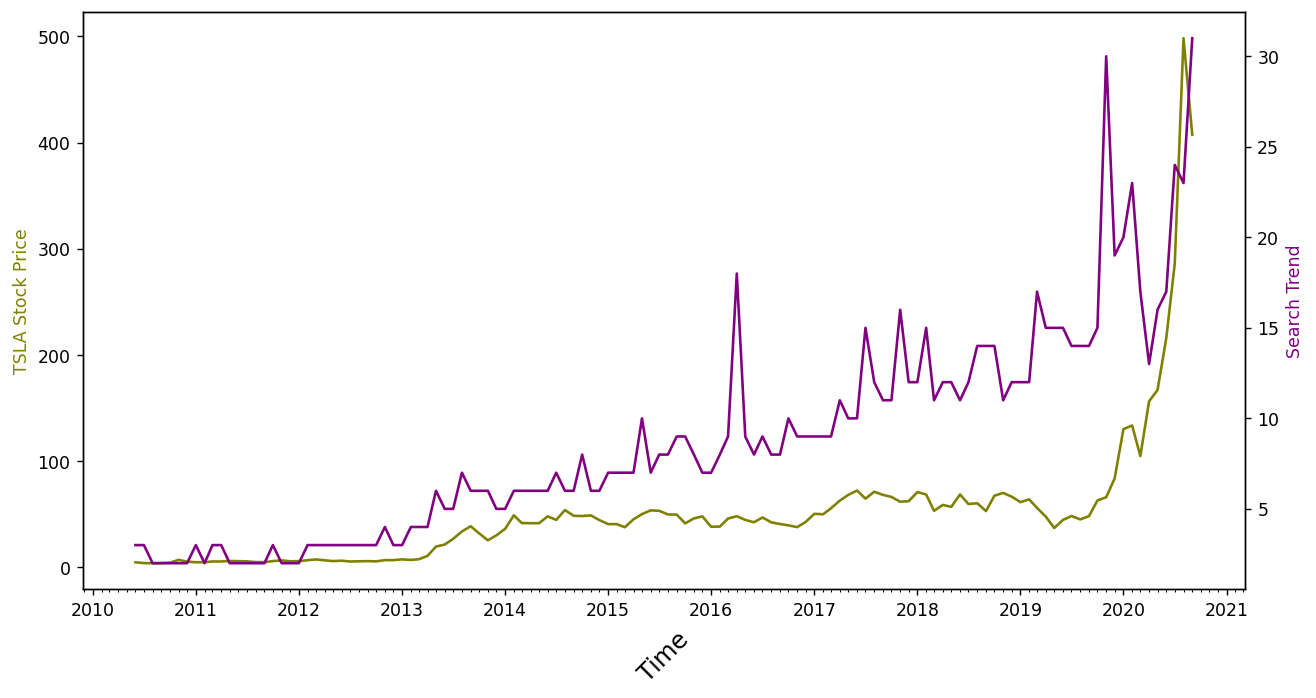

In [140]:

plt.subplots(figsize=(12,6), dpi=125)
plt.xlabel("Time", fontsize='14', rotation=45)

ax1 = plt.gca() #get current axis
ax2 = ax1.twinx()

#set timeline ticks for the x axis
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_minor_locator(months)
ax1.xaxis.set_major_formatter(years_fmt)

ax1.set_ylabel('TSLA Stock Price', color='olive')
ax2.set_ylabel('Search Trend', color='purple')

plt.xticks(rotation=45)

ax1.plot(df_tesla.month, df_tesla.tsla_usd_close, color='olive')
ax2.plot(df_tesla.month, df_tesla.tsla_web_search, color='purple')

### Bitcoin (BTC) Price v.s. Search Volume

**Challenge**: Create the same chart for the Bitcoin Prices vs. Search volumes. <br>
1. Modify the chart title to read 'Bitcoin News Search vs Resampled Price' <br>
2. Change the y-axis label to 'BTC Price' <br>
3. Change the y- and x-axis limits to improve the appearance <br>
4. Investigate the [linestyles](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html ) to make the BTC price a dashed line <br>
5. Investigate the [marker types](https://matplotlib.org/3.2.1/api/markers_api.html) to make the search datapoints little circles <br>
6. Were big increases in searches for Bitcoin accompanied by big increases in the price?

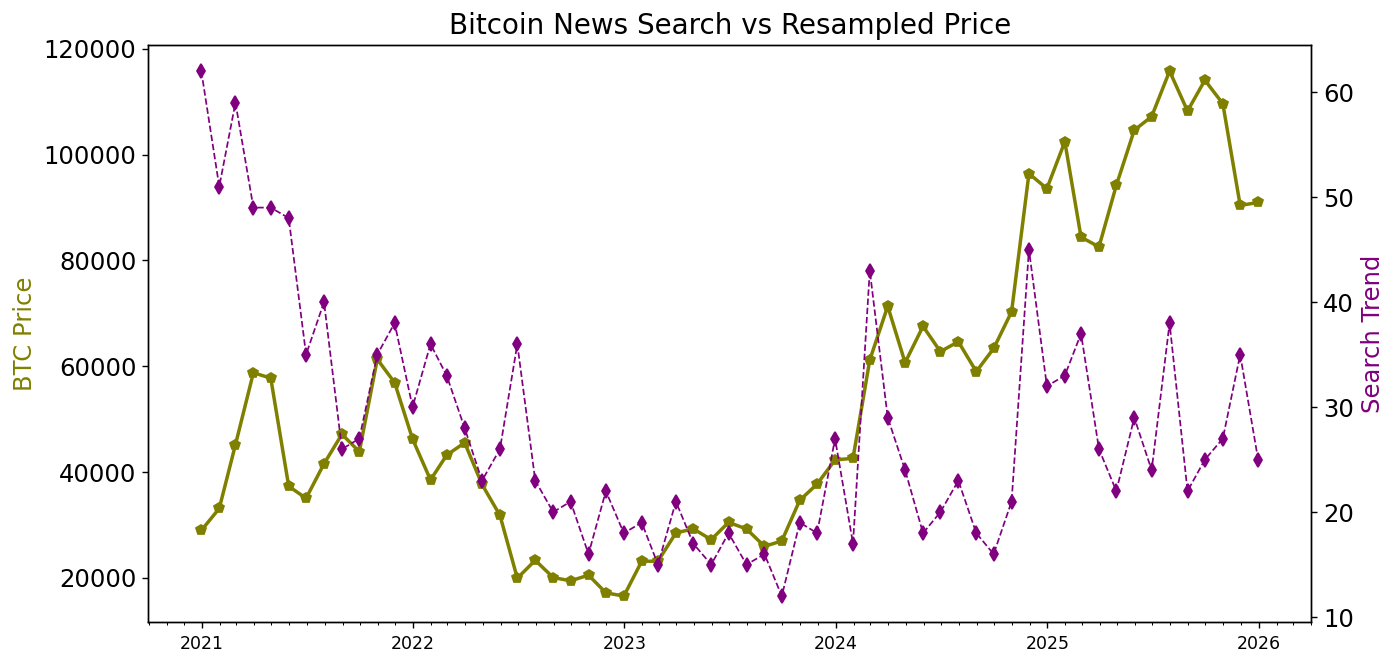

In [141]:
plt.figure(figsize=(12, 6), dpi=125)
plt.title('Bitcoin News Search vs Resampled Price', fontsize=16)

ax1 = plt.gca() #get current axis
ax2 = ax1.twinx()

ax1.set_ylabel('BTC Price', color='olive', fontsize=14)
ax2.set_ylabel('Search Trend', color='purple', fontsize=14)

# ax1.set_ylim(bottom=0, top=1000000) # Adjust y-axis limits for price
# ax2.set_ylim(bottom=0, top=65) # Adjust y-axis limits for search trend

ax1.plot(df_btc_price.index, df_btc_price.Price, color='olive', marker='p', linewidth=2)
ax2.plot(df_btc_search.index, df_btc_search.trend_score, color='purple', linestyle='--', marker='d', linewidth=1)

plt.xlabel('Time', fontsize=14) # Set x-axis label
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

#set timeline ticks for the x axis
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_minor_locator(months)
ax1.xaxis.set_major_formatter(years_fmt)

plt.show()

### Unemployement Benefits Search vs. Actual Unemployment in the U.S.

**Challenge** Plot the search for "unemployment benefits" against the unemployment rate.
1. Change the title to: Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate <br>
2. Change the y-axis label to: FRED U/E Rate <br>
3. Change the axis limits <br>
4. Add a grey [grid](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.grid.html) to the chart to better see the years and the U/E rate values. Use dashes for the line style<br>
5. Can you discern any seasonality in the searches? Is there a pattern?

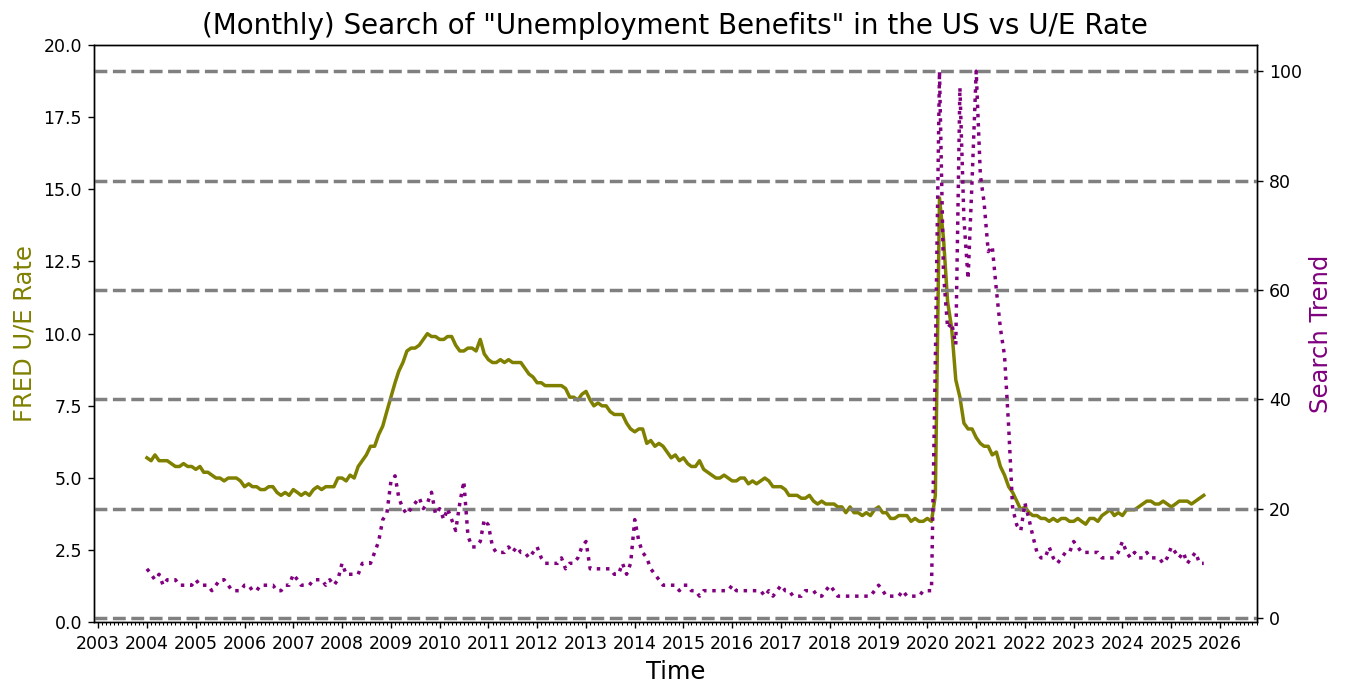

In [142]:
from matplotlib import lines
plt.figure(figsize=(12, 6), dpi=125)
plt.title('(Monthly) Search of "Unemployment Benefits" in the US vs U/E Rate', fontsize=16)

ax1 = plt.gca() #get current axis
ax2 = ax1.twinx()

ax1.set_ylabel("FRED U/E Rate", color='olive', fontsize=14)
ax2.set_ylabel('Search Trend', color='purple', fontsize=14)

ax1.set_xlabel('Time', fontsize=14) # Set x-axis label

ax1.set_ylim(bottom=0, top=20) # set top limit of unemp rate
plt.grid(color='gray', linestyle='--' ,linewidth=2) #set horizontal grid lines

#set timeline ticks for the x axis
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_minor_locator(months)
ax1.xaxis.set_major_formatter(years_fmt)

ax1.plot(df_unemp.month, df_unemp.unemp_rate, color='olive', linewidth=2)
ax2.plot(df_unemp.month, df_unemp.unemp_web_search, color='purple', linewidth=2, linestyle='dotted')

**Challenge**: Calculate the 3-month or 6-month rolling average for the web searches. Plot the 6-month rolling average search data against the actual unemployment. What do you see in the chart? Which line moves first?


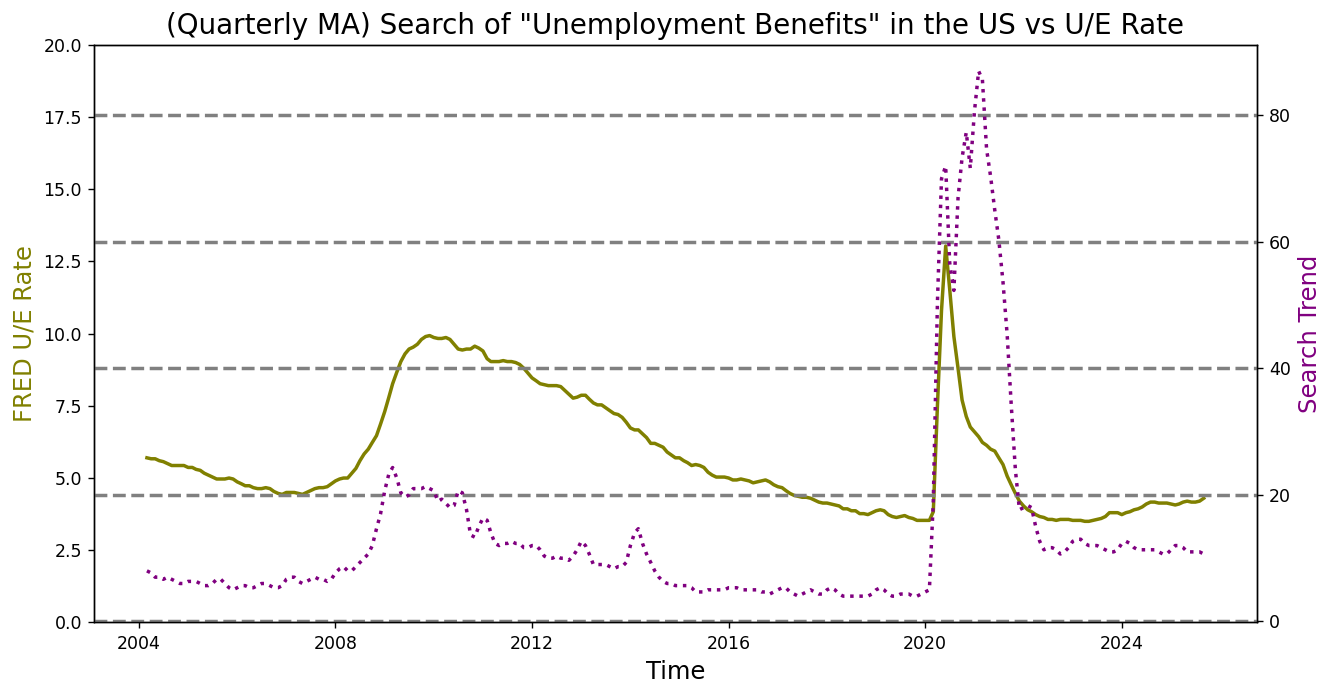

In [149]:
# use .rolling() with window=3 or 6 and .mean()
df_qtr_unemp = df_unemp[['unemp_rate',"unemp_web_search"]].rolling(window=3).mean()

from matplotlib import lines
plt.figure(figsize=(12, 6), dpi=125)
plt.title('(Quarterly MA) Search of "Unemployment Benefits" in the US vs U/E Rate', fontsize=16)

ax1 = plt.gca() #get current axis
ax2 = ax1.twinx()

ax1.set_ylabel("FRED U/E Rate", color='olive', fontsize=14)
ax2.set_ylabel('Search Trend', color='purple', fontsize=14)

ax1.set_xlabel('Time', fontsize=14) # Set x-axis label
plt.xticks(rotation=45, fontsize=14)
ax1.set_ylim(bottom=0, top=20) # set top limit of unemp rate in graph to 11

plt.grid(color='gray', linestyle='--' ,linewidth=2)

#using df_unemp.month for the year ranges and df_qtr_unemp for the MA data generated at the top
ax1.plot(df_unemp.month, df_qtr_unemp.unemp_rate, color='olive', linewidth=2)
ax2.plot(df_unemp.month, df_qtr_unemp.unemp_web_search, color='purple', linewidth=2, linestyle='dotted')
